<div id="container" style="position:relative;">
<div style="float:left"><h1> Data Prep and Exploration</h1></div>
<div style="position:relative; float:right"><img style="height:65px" src ="https://drive.google.com/uc?export=view&id=1EnB0x-fdqMp6I5iMoEBBEuxB_s7AmE2k" />
</div>
</div>



Data preparation and exploratory data analysis (EDA) are two processes that go hand in hand.

Before we can carry out any real meaningful analysis using data we must always go through the process of making sure our dataset is clean and fit for purpose. We can then begin exploring the data itself to build initial intuition about the trends contained within the data that could help us answer further questions or guide us other downstream tasks such as modeling. 

In this codealong we will go through the process of preparing and exploring a new dataset. Our aim is to build comfort using Pandas to clean data and develop a framework we can use whenever we need to clean data.  

### Dataset

We will be using a real world bank marketing dataset. The dataset contains information about customers who were contacted as part of a telephone marketing campaign trying to get customers to sign up for a term deposit product. The dataset also contains information about whether the customer has been contacted as part of the current marketing campaign or had been as part of a previous campaign. 

#### Data Dictionary

To help us with our analysis, take some time to study the data dictionary below. 

Demographic & client data:
- age (numeric)
- job (categorical)
- marital: marital status (categorical, note: 'divorced' means divorced or widowed)
- education (categorical)
- credit_in_default: has credit in default? (categorical)
- housing_loan: has housing loan? (categorical)
- personal_loan: has personal loan? (categorical)

Data about the calls from *this* campaign:
- last_contact_type: contact communication type (categorical)
- last_contact_month: last contact month of year (categorical)
- last_contact_day: last contact day of the week (categorical)
- last_contact_duration: last contact duration, in seconds (numeric)
- last_contact_duration_mins: last contact duration, in minutes (numeric)
- n_contacts_this_campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)

Data about calls from *previous* campaigns:
- n_contacts_prev_campaign: number of contacts performed before this campaign and for this client (numeric)
- prev_campaign_outcome: outcome of the previous marketing campaign (categorical)

Field of interest:
- registered: has the client registered for a term deposit?

### Question of interest

Imagine we work as a data analyst/scientist within the marketing department of the bank which owns this data. Our manger asks us to investigate the following: 

> How do customers who registered for the term deposit product differ from those who did not? This can be in terms of customer demographics or in terms of features of the current and prior marketing campaign. 


### Work Plan

- read in the data, and do some visual inspection
- check for data quality (null values, duplicates, any other issues)
- fix data quality issues
- finally do some EDA (univariate, bivariate, bivariate with respect to target)

In [7]:
# import relevant packages
# holy trinity

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Data Cleaning

The bank has provided us with this snapshot of demographic and campaign data related to the term deposit product. First, let's read in the data and take a look at what we're working with, and assess the level of cleaning and preprocessing that needs to be done.

In [31]:
bank_df = pd.read_csv('bank-marketing-data.csv')

In [4]:
bank_df

,;age;job;marital;education;credit_in_default;housing_loan;personal_loan;last_contact_type;last_contact_month;last_contact_day;last_contact_duration;n_contacts_this_campaign;days_since_last_contact;n_contacts_prev_campaign;prev_campaign_outcome;registered
0,0;38.0;student - Albufeira;divorced;unknown;no...
1,1;34.0;services - Mealhada;married;professiona...
2,2;43.0;housemaid - Vila Franca de Xira;;;unkno...
3,3;75.0;retired - Mirandela;married;basic.4y;no...
4,4;58.0;retired - Funchal;married;unknown;no;un...
...,...
11715,11715;39.0;services - Funchal;divorced;high.sc...
11716,11716;44.0;blue-collar - Moura;;basic.4y;no;ye...
11717,11717;;housemaid - Valongo;divorced;;unknown;n...
11718,11718;35.0;technician - Vila Nova de Santo And...


In [32]:
# whoops 
# not comma delimited, its semicolon delimited

bank_df = pd.read_csv('bank-marketing-data.csv',sep = ";")

In [12]:
bank_df.head(20)

,Unnamed: 0,age,job,marital,education,credit_in_default,housing_loan,personal_loan,last_contact_type,last_contact_month,last_contact_day,last_contact_duration,n_contacts_this_campaign,days_since_last_contact,n_contacts_prev_campaign,prev_campaign_outcome,registered
0,0,38.0,student - Albufeira,divorced,unknown,no,no,no,cellular,may,tue,244.0,3,999,0,nonexistent,no
1,1,34.0,services - Mealhada,married,professional.course,no,no,no,cellular,may,mon,190.0,3,999,0,nonexistent,no
2,2,43.0,housemaid - Vila Franca de Xira,NaN,NaN,unknown,yes,yes,cellular,jul,thu,97.0,2,999,0,nonexistent,no
3,3,75.0,retired - Mirandela,married,basic.4y,no,no,no,cellular,oct,wed,113.0,2,999,0,nonexistent,no
4,4,58.0,retired - Funchal,married,unknown,no,unknown,unknown,telephone,may,tue,174.0,1,999,0,nonexistent,no
5,5,30.0,admin. - Ponte de Sor,single,university.degree,no,no,no,cellular,may,wed,82.0,2,999,1,failure,no
6,6,29.0,services - Queluz,single,high.school,no,yes,no,cellular,nov,wed,178.0,1,999,1,failure,no
7,7,32.0,admin. - Esmoriz,divorced,basic.9y,no,yes,no,cellular,jul,mon,118.0,3,999,0,nonexistent,no
8,8,32.0,blue-collar - Chaves,NaN,university.degree,unknown,yes,no,cellular,nov,tue,63.0,1,999,0,nonexistent,no
9,9,24.0,technician - Agualva-Cacém,NaN,professional.course,unknown,no,no,telephone,may,mon,149.0,4,999,0,nonexistent,no


In [7]:
bank_df.tail()

,Unnamed: 0,age,job,marital,education,credit_in_default,housing_loan,personal_loan,last_contact_type,last_contact_month,last_contact_day,last_contact_duration,n_contacts_this_campaign,days_since_last_contact,n_contacts_prev_campaign,prev_campaign_outcome,registered
11715,11715,39.0,services - Funchal,divorced,high.school,unknown,yes,no,telephone,jun,mon,241.0,5,999,0,nonexistent,no
11716,11716,44.0,blue-collar - Moura,NaN,basic.4y,no,yes,no,cellular,aug,tue,NaN,3,999,0,nonexistent,no
11717,11717,NaN,housemaid - Valongo,divorced,NaN,unknown,no,no,telephone,may,tue,115.0,1,999,0,nonexistent,no
11718,11718,35.0,technician - Vila Nova de Santo André,NaN,professional.course,no,no,no,telephone,mar,thu,282.0,2,6,1,success,no
11719,11719,36.0,blue-collar - Tondela,single,high.school,unknown,no,no,telephone,may,mon,NaN,2,999,0,nonexistent,no


In [33]:
bank_df = pd.read_csv('bank-marketing-data.csv', sep=';', index_col=0)

In [34]:
bank_df.head()

,age,job,marital,education,credit_in_default,housing_loan,personal_loan,last_contact_type,last_contact_month,last_contact_day,last_contact_duration,n_contacts_this_campaign,days_since_last_contact,n_contacts_prev_campaign,prev_campaign_outcome,registered
0,38.0,student - Albufeira,divorced,unknown,no,no,no,cellular,may,tue,244.0,3,999,0,nonexistent,no
1,34.0,services - Mealhada,married,professional.course,no,no,no,cellular,may,mon,190.0,3,999,0,nonexistent,no
2,43.0,housemaid - Vila Franca de Xira,NaN,NaN,unknown,yes,yes,cellular,jul,thu,97.0,2,999,0,nonexistent,no
3,75.0,retired - Mirandela,married,basic.4y,no,no,no,cellular,oct,wed,113.0,2,999,0,nonexistent,no
4,58.0,retired - Funchal,married,unknown,no,unknown,unknown,telephone,may,tue,174.0,1,999,0,nonexistent,no


some observations:

- it appears that job contains more than just job information, we'll want to split job and location into two seperate columns
- we see some Null values
- some categorical columns have an unknown category
- days since last contact has '999' as a value, which seems weird.

but before we start cleaning data (addressing the points above) let's learn more about the dimensions and the data types

In [35]:
bank_df.shape

(11720, 16)

In [36]:
print(f"the bank marketing df has {bank_df.shape[0]} rows and {bank_df.shape[1]} columns")

the bank marketing df has 11720 rows and 16 columns


to get a high level overview of the 16 columns, we can use the info() method

In [37]:
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 11720 entries, 0 to 11719
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       11132 non-null  float64
 1   job                       11027 non-null  object 
 2   marital                   10992 non-null  object 
 3   education                 11005 non-null  object 
 4   credit_in_default         11720 non-null  object 
 5   housing_loan              11720 non-null  object 
 6   personal_loan             11720 non-null  object 
 7   last_contact_type         11720 non-null  object 
 8   last_contact_month        11720 non-null  object 
 9   last_contact_day          11720 non-null  object 
 10  last_contact_duration     8841 non-null   float64
 11  n_contacts_this_campaign  11720 non-null  int64  
 12  days_since_last_contact   11720 non-null  int64  
 13  n_contacts_prev_campaign  11720 non-null  int64  
 14  prev_c

In [38]:
bank_df.describe()

,age,last_contact_duration,n_contacts_this_campaign,days_since_last_contact,n_contacts_prev_campaign
count,11132.000000,8841.000000,11720.000000,11720.000000,11720.000000
mean,40.376662,349.068884,2.374403,908.414932,0.275768
std,11.703574,338.588752,2.406386,285.946506,0.656495
min,17.000000,1.000000,1.000000,0.000000,0.000000
25%,32.000000,130.000000,1.000000,999.000000,0.000000
50%,38.000000,232.000000,2.000000,999.000000,0.000000
75%,48.000000,458.000000,3.000000,999.000000,0.000000
max,98.000000,4918.000000,39.000000,999.000000,6.000000


11 object columns, 5 numeric

we have 5 columns with missing data (2 are numeric and 3 are object)

recall the days since last contact value 999, we can look into that further now

In [39]:
bank_df['days_since_last_contact'].value_counts()

999    10651
3        329
6        318
4         76
7         44
2         41
9         40
10        35
5         29
12        28
13        28
15        17
11        15
8         12
14        12
0         11
1         11
16         7
17         4
18         4
21         2
22         2
25         1
26         1
27         1
19         1
Name: days_since_last_contact, dtype: int64

maybe this means that over 10k (out of almost 12k) customers were never contacted. we can investigate this by making a cross tabulation between days since last contact and another column that contains information about customer contacts, like last contact type.

In [40]:
# cross tabulation

pd.crosstab(bank_df['days_since_last_contact'],bank_df['last_contact_type'])

last_contact_type,cellular,telephone
days_since_last_contact,,
0,10,1
1,10,1
2,38,3
3,305,24
4,72,4
5,27,2
6,290,28
7,40,4
8,10,2


These customers HAVE been contacted, so we still don't have a good understanding of what 999 means. we will revisit this issue, and its a good question to raise with the marketing data team if we have a chance to follow up with them. we will table this issue for now.

### data cleaning to-do list

- extract location from the job column
- see if there are any duplicate rows or columns (if there are, make judgement too drop or not)
- impute null values or we might consider dropping columns with a lot of nulls.

In [41]:
bank_df['job'].head(15)

0                   student - Albufeira
1                   services - Mealhada
2       housemaid - Vila Franca de Xira
3                   retired - Mirandela
4                     retired - Funchal
5                 admin. - Ponte de Sor
6                     services - Queluz
7                      admin. - Esmoriz
8                  blue-collar - Chaves
9            technician - Agualva-Cacém
10                blue-collar - Valongo
11                technician - Portimão
12                    unknown - Peniche
13    services - Vila Nova de Famalicão
14               blue-collar - Trancoso
Name: job, dtype: object

In [42]:
"student - Albufeira".split(" - ")

['student', 'Albufeira']

can we apply this directly to job column?

In [43]:
bank_df['job'].str.split(" - ",expand = True)

,0,1
0,student,Albufeira
1,services,Mealhada
2,housemaid,Vila Franca de Xira
3,retired,Mirandela
4,retired,Funchal
...,...,...
11715,services,Funchal
11716,blue-collar,Moura
11717,housemaid,Valongo
11718,technician,Vila Nova de Santo André


In [44]:
bank_df['job']

0                          student - Albufeira
1                          services - Mealhada
2              housemaid - Vila Franca de Xira
3                          retired - Mirandela
4                            retired - Funchal
                         ...                  
11715                       services - Funchal
11716                      blue-collar - Moura
11717                      housemaid - Valongo
11718    technician - Vila Nova de Santo André
11719                    blue-collar - Tondela
Name: job, Length: 11720, dtype: object

we'll proceed by writing this string split to a new data frame object, and then overwrite/add new columns to our bank_df data frame.

In [45]:
# write to dataframe

string_df = bank_df['job'].str.split(" - ",expand = True)

# overwrite the job column

bank_df['job'] = string_df[0]

# add location to bank_df

bank_df['location'] = string_df[1]

In [46]:
# check to see what happened

bank_df.head(10)

,age,job,marital,education,credit_in_default,housing_loan,personal_loan,last_contact_type,last_contact_month,last_contact_day,last_contact_duration,n_contacts_this_campaign,days_since_last_contact,n_contacts_prev_campaign,prev_campaign_outcome,registered,location
0,38.0,student,divorced,unknown,no,no,no,cellular,may,tue,244.0,3,999,0,nonexistent,no,Albufeira
1,34.0,services,married,professional.course,no,no,no,cellular,may,mon,190.0,3,999,0,nonexistent,no,Mealhada
2,43.0,housemaid,NaN,NaN,unknown,yes,yes,cellular,jul,thu,97.0,2,999,0,nonexistent,no,Vila Franca de Xira
3,75.0,retired,married,basic.4y,no,no,no,cellular,oct,wed,113.0,2,999,0,nonexistent,no,Mirandela
4,58.0,retired,married,unknown,no,unknown,unknown,telephone,may,tue,174.0,1,999,0,nonexistent,no,Funchal
5,30.0,admin.,single,university.degree,no,no,no,cellular,may,wed,82.0,2,999,1,failure,no,Ponte de Sor
6,29.0,services,single,high.school,no,yes,no,cellular,nov,wed,178.0,1,999,1,failure,no,Queluz
7,32.0,admin.,divorced,basic.9y,no,yes,no,cellular,jul,mon,118.0,3,999,0,nonexistent,no,Esmoriz
8,32.0,blue-collar,NaN,university.degree,unknown,yes,no,cellular,nov,tue,63.0,1,999,0,nonexistent,no,Chaves
9,24.0,technician,NaN,professional.course,unknown,no,no,telephone,may,mon,149.0,4,999,0,nonexistent,no,Agualva-Cacém


let's now turn our attention to duplicates

In [47]:
bank_df.duplicated().sum()

51

51 duplicates does not seem like a lot

50 out of 10k observations, that's half a percent

let's quickly verify, what fraction of our observations are duplicates

In [27]:
print(f"{round(bank_df.duplicated().sum()/bank_df.shape[0]*100,3)}%")

0.435%


the scale of the problem is minimal, and its fair to ask, are these even duplicates?

In [29]:
bank_df[bank_df.duplicated(keep = False)].sort_values(by = ['location','age']).head()

,age,job,marital,education,credit_in_default,housing_loan,personal_loan,last_contact_type,last_contact_month,last_contact_day,last_contact_duration,n_contacts_this_campaign,days_since_last_contact,n_contacts_prev_campaign,prev_campaign_outcome,registered,location
39,32.0,technician,single,professional.course,no,yes,no,cellular,apr,mon,54.0,1,999,0,nonexistent,no,Agualva-Cacém
11713,32.0,technician,single,professional.course,no,yes,no,cellular,apr,mon,54.0,1,999,0,nonexistent,no,Agualva-Cacém
6063,36.0,housemaid,married,basic.4y,no,yes,yes,cellular,jul,mon,120.0,6,999,0,nonexistent,no,Agualva-Cacém
11698,36.0,housemaid,married,basic.4y,no,yes,yes,cellular,jul,mon,120.0,6,999,0,nonexistent,no,Agualva-Cacém
2994,NaN,retired,married,basic.6y,no,unknown,unknown,telephone,jun,mon,NaN,5,999,0,nonexistent,no,Agualva-Cacém


they might be duplicates, it seems unlikely that two people would share all this information in common. We will drop the duplicates, and follow up with the marketing data team to see what they think.

In [49]:
bank_df2 = bank_df.drop_duplicates()

In [50]:
# test

bank_df.shape[0] - bank_df2.shape[0]

51

we should also check if any of the columns in bank_df2 are perfect duplicates of each other

In [51]:
bank_df2.T.duplicated().sum()

0

another trick to identifying duplicated information in (numerical) columns is to compute pairwise correlations between columns, and look for perfect correlation (1 or -1). 

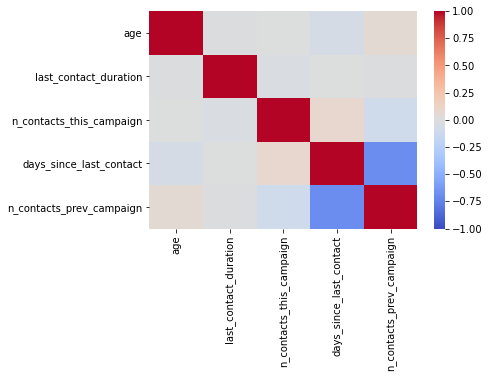

In [34]:
plt.figure()
sns.heatmap(bank_df2.corr(),cmap = 'coolwarm',vmin=-1,vmax=1)
plt.show()

toy example: two columns that are perfectly correlated

In [35]:
x_sample = np.random.rand(20,1)

In [36]:
y_sample = 12*x_sample

In [37]:
xy_sample = np.concatenate([x_sample,y_sample],axis = 1)

In [38]:
np.corrcoef(xy_sample,rowvar = False)

array([[1., 1.],
       [1., 1.]])

how do we identify perfect duplication across categorical columns?

- take a cross tab of the two columns and look for perfect alignment between categories
- use domain knowledge to judge if the categories across the two columns have similar or identical meanings

we've taken care of duplicates, let's now turn our attention to nulls

In [54]:
bank_df2.columns

Index(['age', 'job', 'marital', 'education', 'credit_in_default',
       'housing_loan', 'personal_loan', 'last_contact_type',
       'last_contact_month', 'last_contact_day', 'last_contact_duration',
       'n_contacts_this_campaign', 'days_since_last_contact',
       'n_contacts_prev_campaign', 'prev_campaign_outcome', 'registered',
       'location'],
      dtype='object')

In [56]:
for col in bank_df2.columns:
    
    null_count = bank_df2[col].isnull().sum()
    
    if null_count > 0:
        
        print(col, null_count)

age 582
job 689
marital 720
education 711
last_contact_duration 2865
location 689


In [58]:
bank_df2.isna().sum()/bank_df2.shape[0]*100

age                          4.987574
job                          5.904533
marital                      6.170195
education                    6.093067
credit_in_default            0.000000
housing_loan                 0.000000
personal_loan                0.000000
last_contact_type            0.000000
last_contact_month           0.000000
last_contact_day             0.000000
last_contact_duration       24.552232
n_contacts_this_campaign     0.000000
days_since_last_contact      0.000000
n_contacts_prev_campaign     0.000000
prev_campaign_outcome        0.000000
registered                   0.000000
location                     5.904533
dtype: float64

### Missing data in age

In [46]:
# there are a range of imputation strategies
# varying from simple to complex
# we will stay on the simpler side of things today

bank_df2['age'].mean()

40.37963380535763

In [47]:
bank_df2['age'].median()

38.0

In [49]:
# what is the most common age

bank_df2['age'].mode()[0]

31.0

In [59]:
# write a function to generate histogram and 
# vertical lines corresponding to mean median and mode

def histogram_with_central_tendencies(column):
    
    plt.figure()
    plt.hist(bank_df2[column],bins = 25,color = 'grey')
    plt.xlabel(column)
    plt.axvline(bank_df2[column].mean(),label = 'mean',color = 'red')
    plt.axvline(bank_df2[column].median(),label = 'median',color = 'blue')
    plt.axvline(bank_df2[column].mode()[0],label = 'mode',color = 'black')
    plt.legend()
    plt.title(column)
    plt.show()

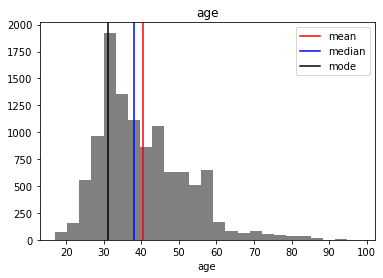

In [60]:
# test

histogram_with_central_tendencies('age')

after some deliberation, we have decided to impute with the median

In [54]:
bank_df2['age'] = bank_df2['age'].fillna(bank_df2['age'].median())

/var/folders/75/y5vk4cds2zb6ps8h27_tl8vc0000gp/T/ipykernel_13321/2066346148.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bank_df2['age'] = bank_df2['age'].fillna(bank_df2['age'].median())


In [55]:
# check if null values are resolved

bank_df2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 11669 entries, 0 to 11669
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       11669 non-null  float64
 1   job                       10980 non-null  object 
 2   marital                   10949 non-null  object 
 3   education                 10958 non-null  object 
 4   credit_in_default         11669 non-null  object 
 5   housing_loan              11669 non-null  object 
 6   personal_loan             11669 non-null  object 
 7   last_contact_type         11669 non-null  object 
 8   last_contact_month        11669 non-null  object 
 9   last_contact_day          11669 non-null  object 
 10  last_contact_duration     8804 non-null   float64
 11  n_contacts_this_campaign  11669 non-null  int64  
 12  days_since_last_contact   11669 non-null  int64  
 13  n_contacts_prev_campaign  11669 non-null  int64  
 14  prev_c

now that we've taken care of age, let's look at last contact duration (a lot of nulls, 25%)

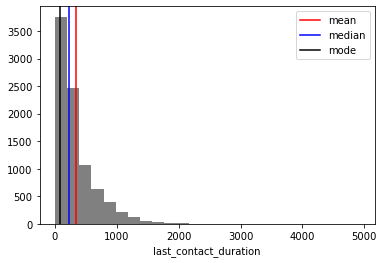

In [56]:
histogram_with_central_tendencies('last_contact_duration')

In [57]:
bank_df2['last_contact_duration'].mode()[0]

89.0

In [58]:
bank_df2['last_contact_duration'].median()

232.5

imputing with the median again seems reasonable

In [61]:
bank_df2['last_contact_duration'] = bank_df2['last_contact_duration'].fillna(bank_df2['last_contact_duration'].median())

C:\Users\Virajk\AppData\Local\Temp/ipykernel_1588/2285394663.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bank_df2['last_contact_duration'] = bank_df2['last_contact_duration'].fillna(bank_df2['last_contact_duration'].median())


In [60]:
bank_df2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 11669 entries, 0 to 11669
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       11669 non-null  float64
 1   job                       10980 non-null  object 
 2   marital                   10949 non-null  object 
 3   education                 10958 non-null  object 
 4   credit_in_default         11669 non-null  object 
 5   housing_loan              11669 non-null  object 
 6   personal_loan             11669 non-null  object 
 7   last_contact_type         11669 non-null  object 
 8   last_contact_month        11669 non-null  object 
 9   last_contact_day          11669 non-null  object 
 10  last_contact_duration     11669 non-null  float64
 11  n_contacts_this_campaign  11669 non-null  int64  
 12  days_since_last_contact   11669 non-null  int64  
 13  n_contacts_prev_campaign  11669 non-null  int64  
 14  prev_c

In [72]:
# create a function for making bar charts

def horizontal_bar_for_columns(column,fig_width = 10,fig_height = 10):
    
    plt.figure(figsize = (fig_width,fig_height))
    bank_df2[column].value_counts().sort_values().plot(kind = 'barh',color = 'cornflowerblue')
    plt.title(column)
    plt.show()

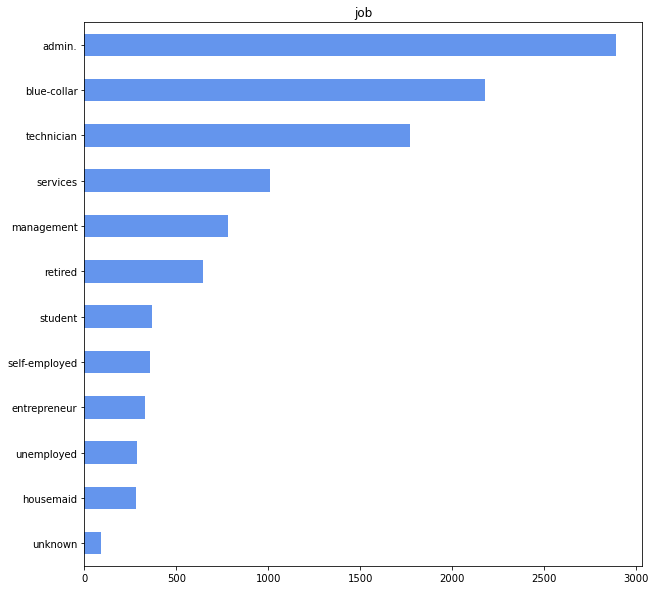

In [73]:
horizontal_bar_for_columns('job')

job already has an unknown category, we can lump in NULL values in this category.

In [74]:
bank_df2['job'] = bank_df2['job'].fillna('unknown')

C:\Users\Virajk\AppData\Local\Temp/ipykernel_1588/1545774254.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bank_df2['job'] = bank_df2['job'].fillna('unknown')


In [64]:
bank_df2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 11669 entries, 0 to 11669
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       11669 non-null  float64
 1   job                       11669 non-null  object 
 2   marital                   10949 non-null  object 
 3   education                 10958 non-null  object 
 4   credit_in_default         11669 non-null  object 
 5   housing_loan              11669 non-null  object 
 6   personal_loan             11669 non-null  object 
 7   last_contact_type         11669 non-null  object 
 8   last_contact_month        11669 non-null  object 
 9   last_contact_day          11669 non-null  object 
 10  last_contact_duration     11669 non-null  float64
 11  n_contacts_this_campaign  11669 non-null  int64  
 12  days_since_last_contact   11669 non-null  int64  
 13  n_contacts_prev_campaign  11669 non-null  int64  
 14  prev_c

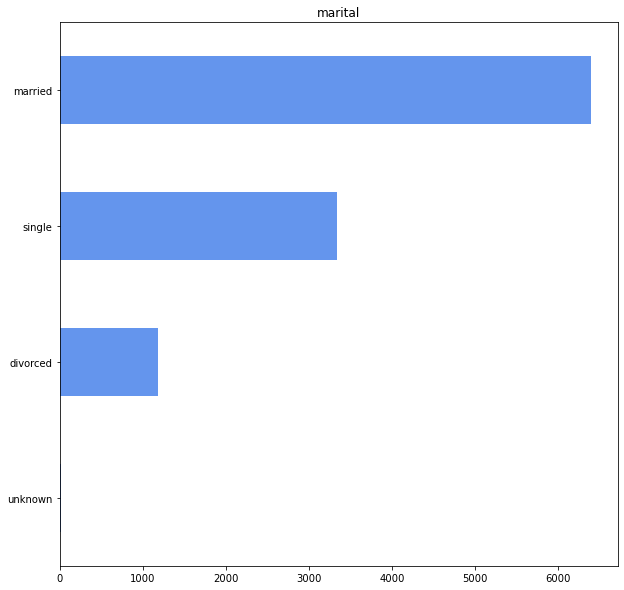

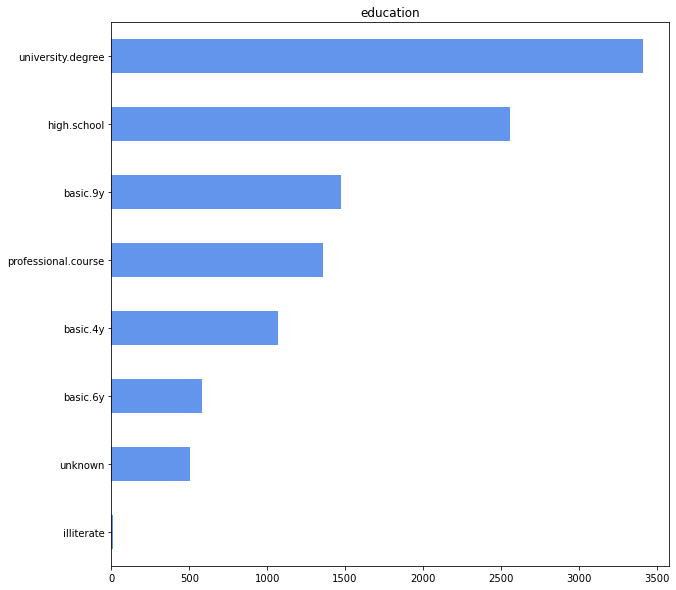

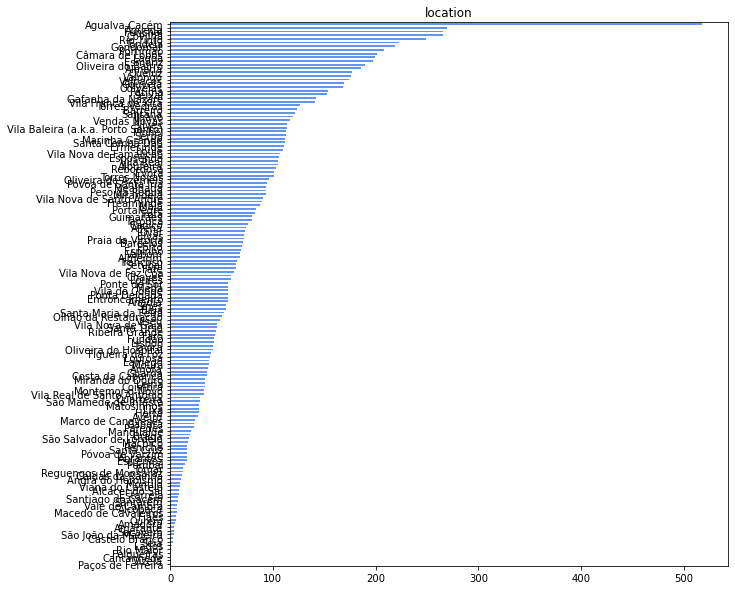

In [65]:
for col in ['marital','education','location']:
    
    horizontal_bar_for_columns(col)

marital and education both have unknown category, harder to tell with location, so lets change the figure dimensions

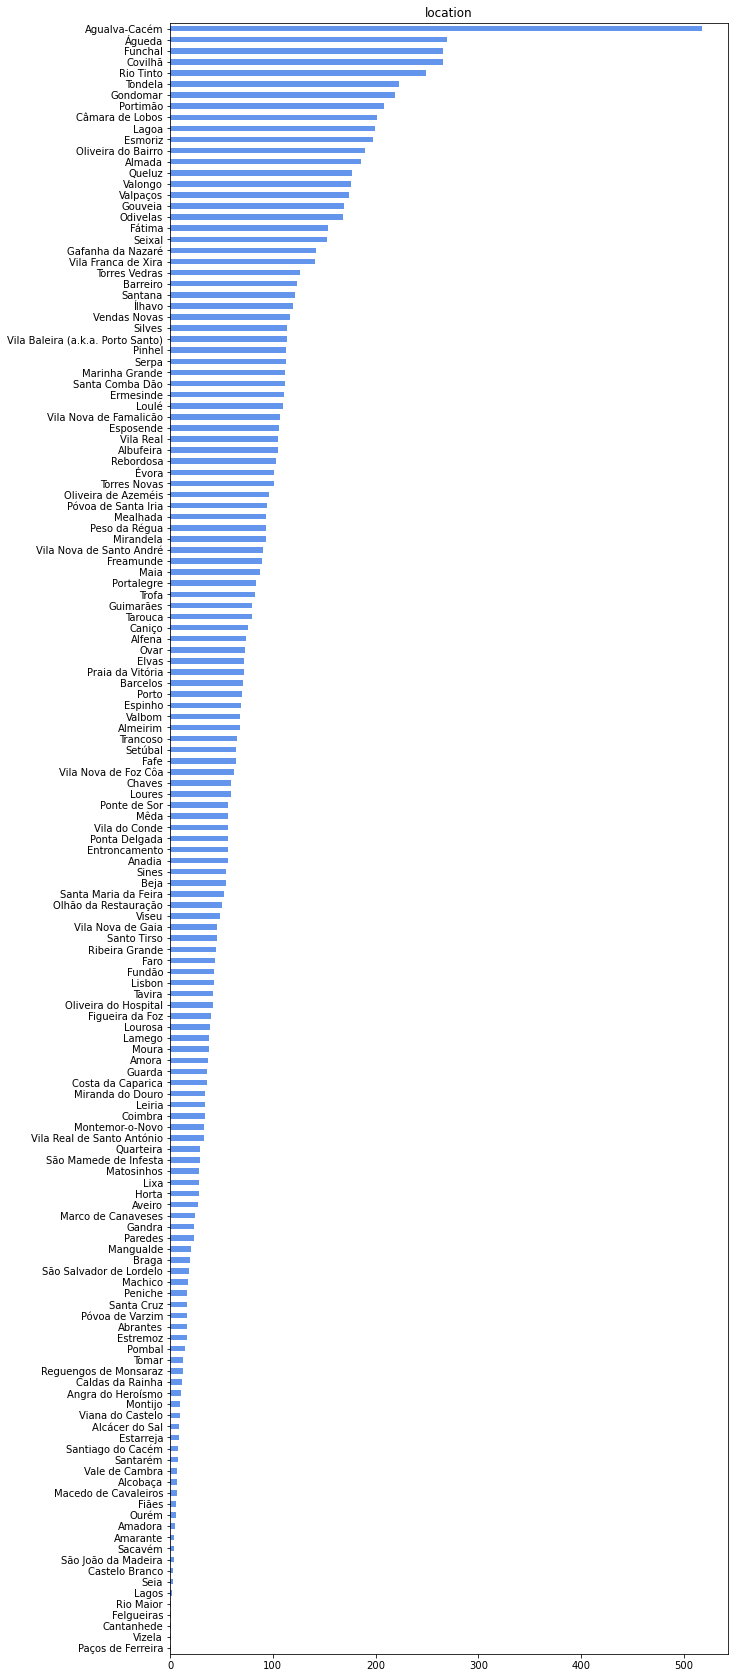

In [67]:
horizontal_bar_for_columns('location',fig_height = 30)

In [68]:
# impute the final three columns with the unknown category

for col in ['marital','education','location']:
    
    bank_df2[col] = bank_df2[col].fillna('unknown')

/var/folders/75/y5vk4cds2zb6ps8h27_tl8vc0000gp/T/ipykernel_13321/1120958216.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bank_df2[col] = bank_df2[col].fillna('unknown')


final check to see if there are still nulls

In [70]:
bank_df2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 11669 entries, 0 to 11669
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       11669 non-null  float64
 1   job                       11669 non-null  object 
 2   marital                   11669 non-null  object 
 3   education                 11669 non-null  object 
 4   credit_in_default         11669 non-null  object 
 5   housing_loan              11669 non-null  object 
 6   personal_loan             11669 non-null  object 
 7   last_contact_type         11669 non-null  object 
 8   last_contact_month        11669 non-null  object 
 9   last_contact_day          11669 non-null  object 
 10  last_contact_duration     11669 non-null  float64
 11  n_contacts_this_campaign  11669 non-null  int64  
 12  days_since_last_contact   11669 non-null  int64  
 13  n_contacts_prev_campaign  11669 non-null  int64  
 14  prev_c

### Exploratory Data Analysis (EDA)
Now that we've cleaned the data, let's do some analysis to address our original question: "What are the characteristics of the customers who register for the term deposit account?"

We will divide our data into categorical and numeric and proceed in this way.

how many people registered and how many didn't?

In [71]:
bank_df2['registered'].value_counts()

no     7030
yes    4639
Name: registered, dtype: int64

In [72]:
bank_df2['registered'].value_counts()/bank_df2.shape[0]

no     0.602451
yes    0.397549
Name: registered, dtype: float64

proceeding to split the data by type

In [73]:
# categorical data

categorical_df = bank_df2.select_dtypes('object')

In [74]:
categorical_df.head()

,job,marital,education,credit_in_default,housing_loan,personal_loan,last_contact_type,last_contact_month,last_contact_day,prev_campaign_outcome,registered,location
0,student,divorced,unknown,no,no,no,cellular,may,tue,nonexistent,no,Albufeira
1,services,married,professional.course,no,no,no,cellular,may,mon,nonexistent,no,Mealhada
2,housemaid,unknown,unknown,unknown,yes,yes,cellular,jul,thu,nonexistent,no,Vila Franca de Xira
3,retired,married,basic.4y,no,no,no,cellular,oct,wed,nonexistent,no,Mirandela
4,retired,married,unknown,no,unknown,unknown,telephone,may,tue,nonexistent,no,Funchal


In [79]:
for col in categorical_df.columns:
    
    print(col)

job
marital
education
credit_in_default
housing_loan
personal_loan
last_contact_type
last_contact_month
last_contact_day
prev_campaign_outcome
registered
location


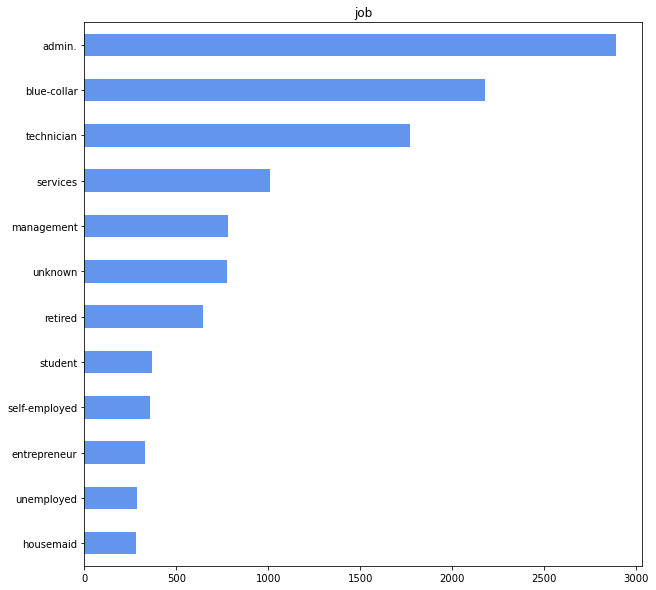

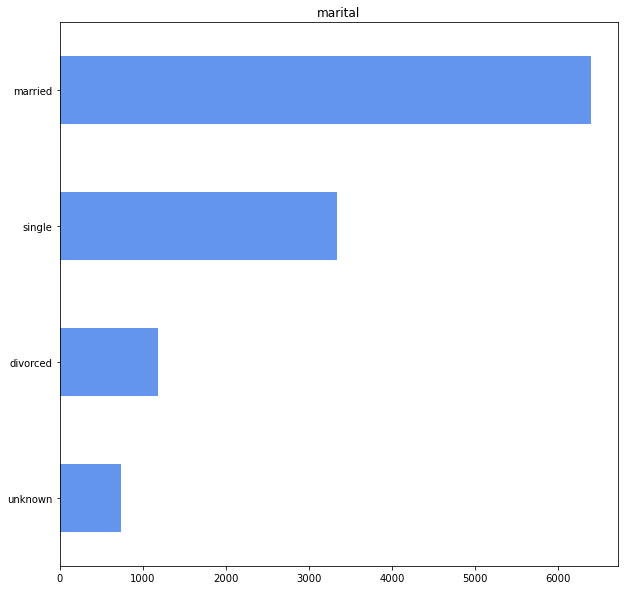

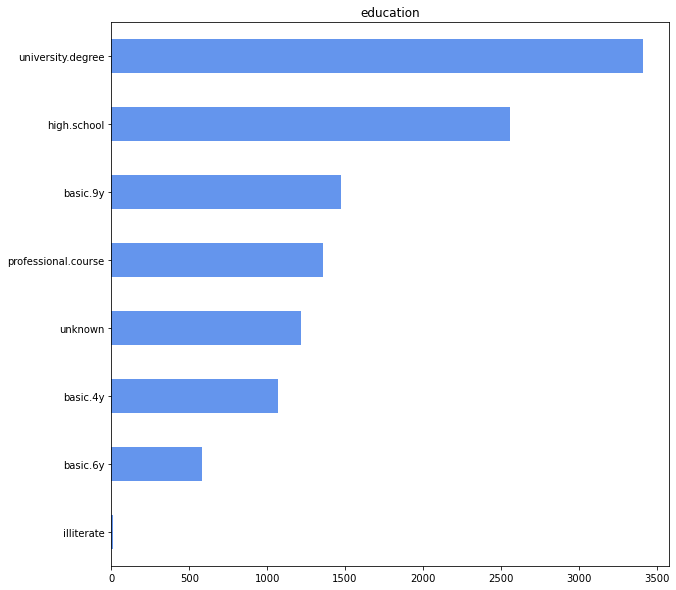

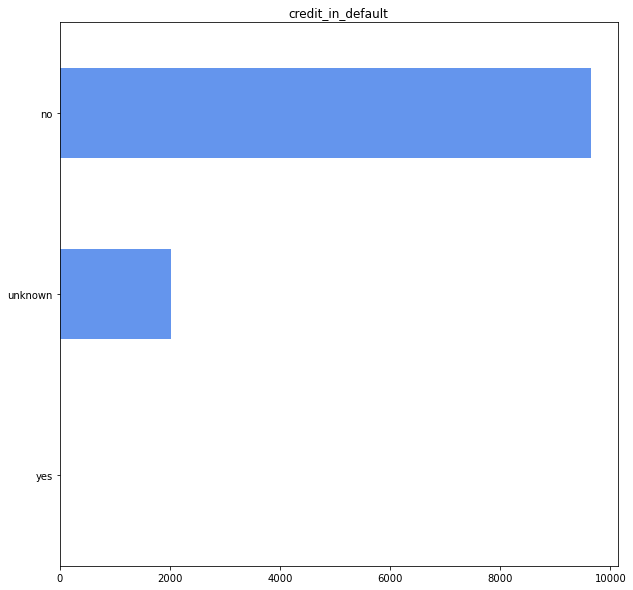

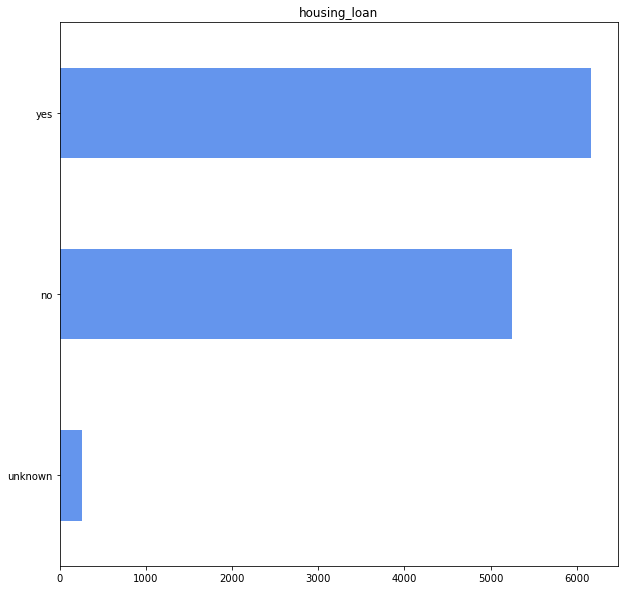

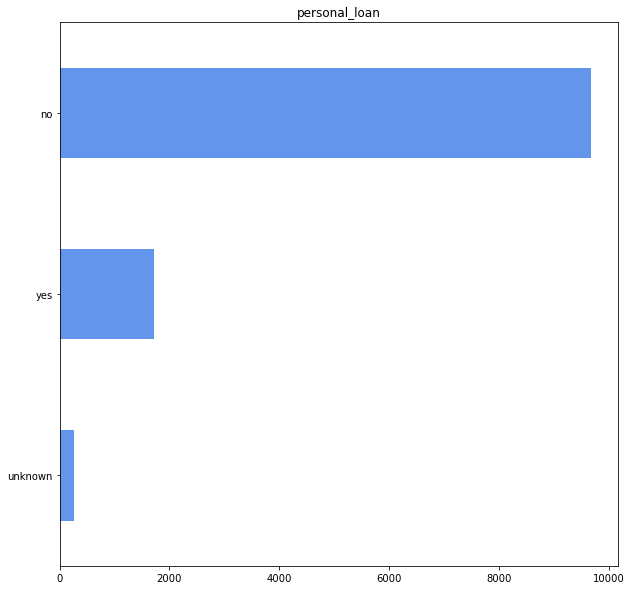

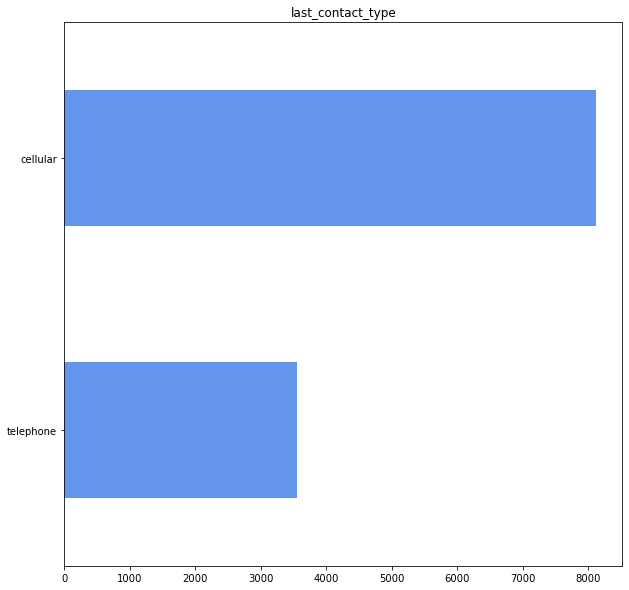

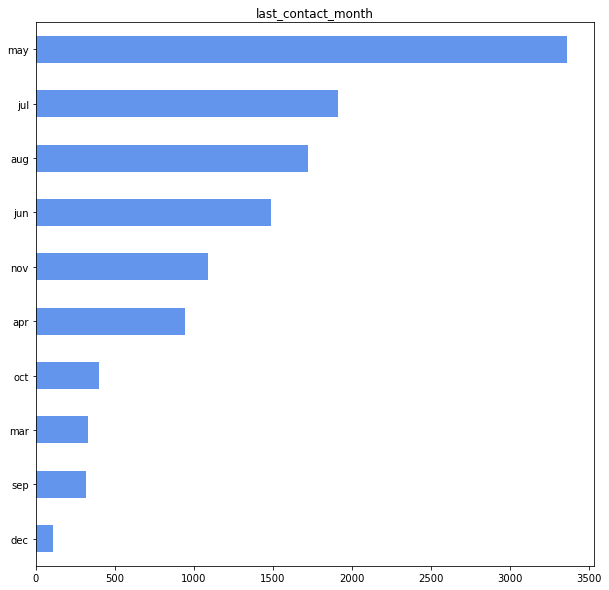

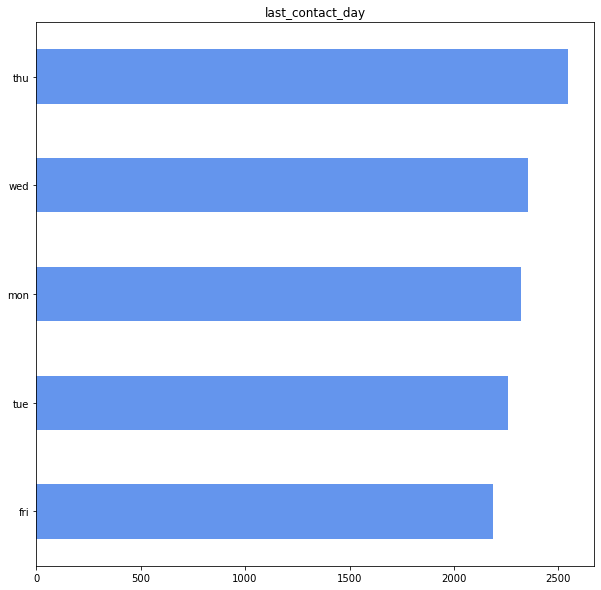

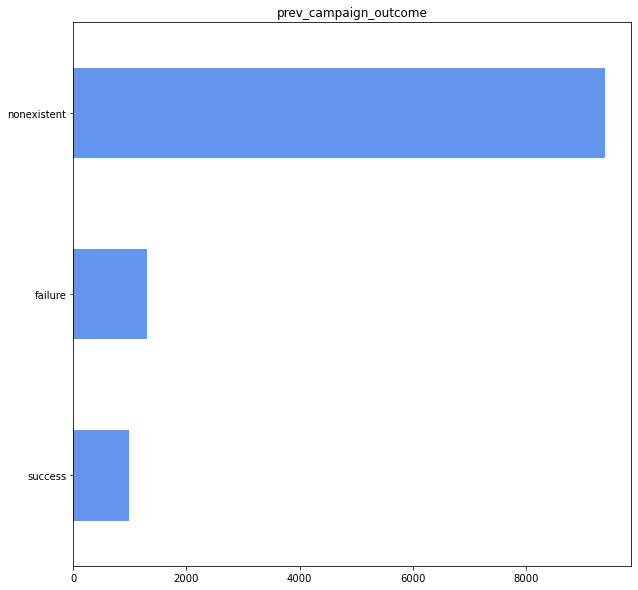

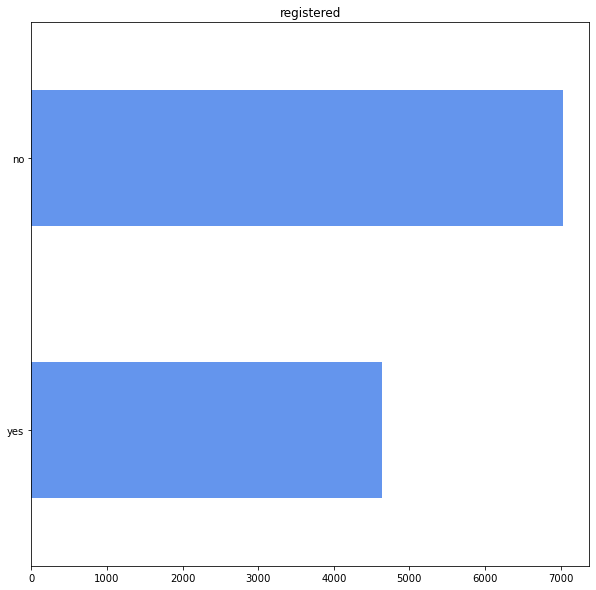

In [77]:
for col in categorical_df.columns[:-1]:
    
    horizontal_bar_for_columns(col)

observations regarding categorical variables

- admin and blue collar are the most common jobs amongst customers
- just about half, maybe more, of customers are married
- most of the customers have 'at least' a HS education
- large majority of customers don't have credit in default
- majority are homeowners
- most do not have a personal loan
- mostly contacted on their cellular, and are contacted during summer months, never on weekends
- most people were not part of the last campaign


In [80]:
bank_df2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 11669 entries, 0 to 11669
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       11669 non-null  float64
 1   job                       11669 non-null  object 
 2   marital                   11669 non-null  object 
 3   education                 11669 non-null  object 
 4   credit_in_default         11669 non-null  object 
 5   housing_loan              11669 non-null  object 
 6   personal_loan             11669 non-null  object 
 7   last_contact_type         11669 non-null  object 
 8   last_contact_month        11669 non-null  object 
 9   last_contact_day          11669 non-null  object 
 10  last_contact_duration     11669 non-null  float64
 11  n_contacts_this_campaign  11669 non-null  int64  
 12  days_since_last_contact   11669 non-null  int64  
 13  n_contacts_prev_campaign  11669 non-null  int64  
 14  prev_c

In [79]:
numeric_df = bank_df2.select_dtypes(['float64','int64'])

In [81]:
numeric_df.head()

,age,last_contact_duration,n_contacts_this_campaign,days_since_last_contact,n_contacts_prev_campaign
0,38.0,244.0,3,999,0
1,34.0,190.0,3,999,0
2,43.0,97.0,2,999,0
3,75.0,113.0,2,999,0
4,58.0,174.0,1,999,0


In [76]:
# don't need to type 64, this works too

numeric_df_test = bank_df2.select_dtypes(['float','int'])

In [80]:
numeric_df_test.head()

,age,last_contact_duration,n_contacts_this_campaign,days_since_last_contact,n_contacts_prev_campaign
0,38.0,244.0,3,999,0
1,34.0,190.0,3,999,0
2,43.0,97.0,2,999,0
3,75.0,113.0,2,999,0
4,58.0,174.0,1,999,0


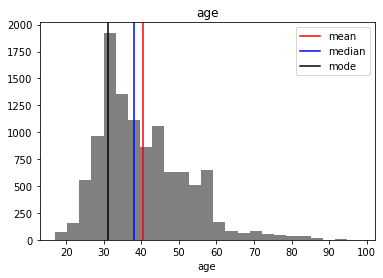

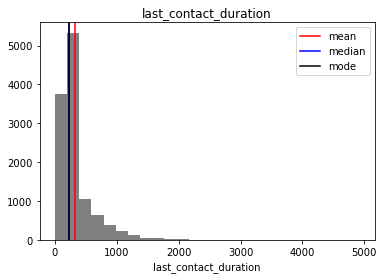

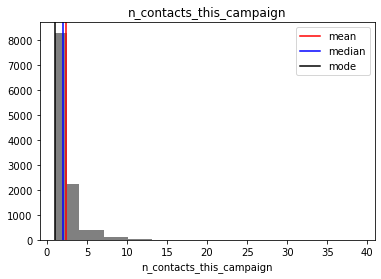

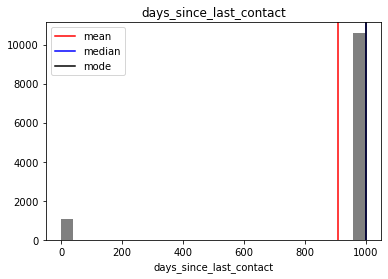

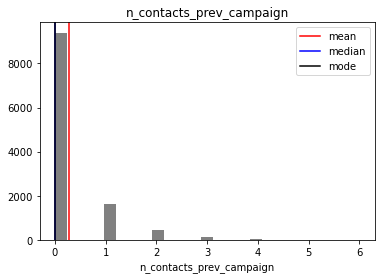

In [82]:
# histogram

for col in numeric_df.columns:
    
    histogram_with_central_tendencies(col)

### bivariate analysis - numeric variables

what is the relationship between the target variable and the various descriptor variables

In [88]:
# starting simple, what is the difference in mean of numeric variables between
# registered or not

bank_df2.groupby('registered').mean()

,age,last_contact_duration,n_contacts_this_campaign,days_since_last_contact,n_contacts_prev_campaign
registered,,,,,
no,39.918492,222.251138,2.587767,985.149360,0.132859
yes,40.779909,468.981893,2.051951,791.990946,0.492779


We can get a more complete story by looking at the distributions rather than just the means.

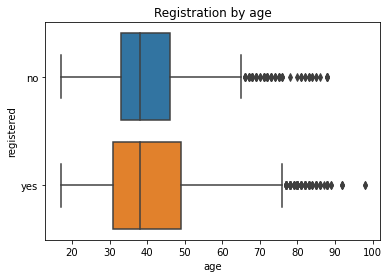

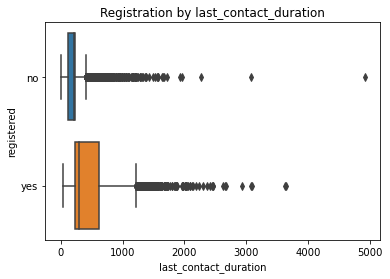

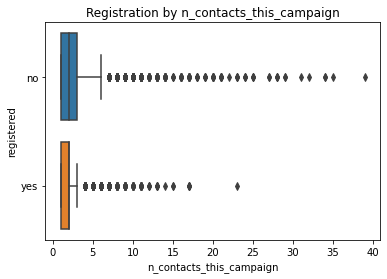

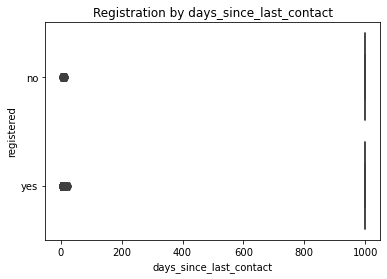

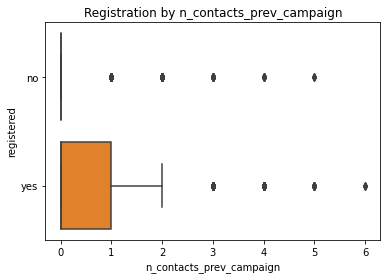

In [96]:
# Converting the registered column to string type so seaborn treats it as a category
for col in numeric_df.columns: 
    
    # Normalize the histogram by passing in 'stat=density' to account for differences in 
    # counts by class.
    sns.boxplot(x=col, y='registered', data=bank_df2)
    plt.title(f'Registration by {col}')
    plt.show()

- There does appear to be an effect of age on registration. For the most part, older people 60+ appear to be more likely to register than not. There also appears to be slightly more young people <= 25. This ties up with what we saw from the `job` column where 'Students' and 'Retirees' had much higher proportions of people registering than on average.   
- Being contacted more times in the previous campaign generally leads to more registrations

### bivariate analysis - categorical variables

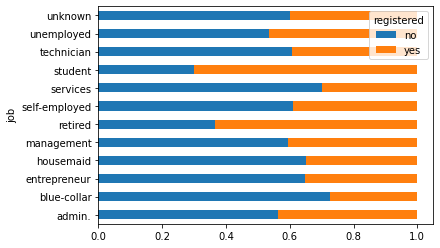

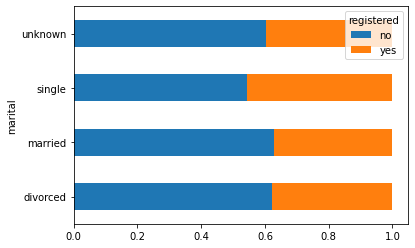

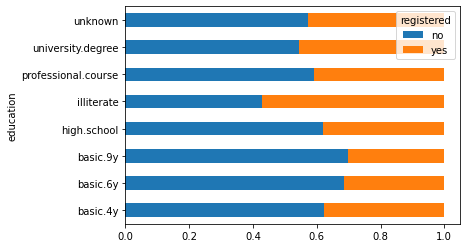

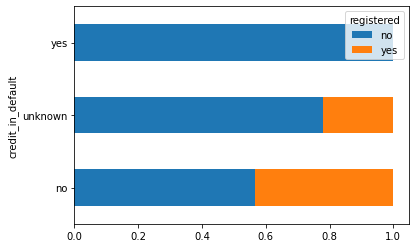

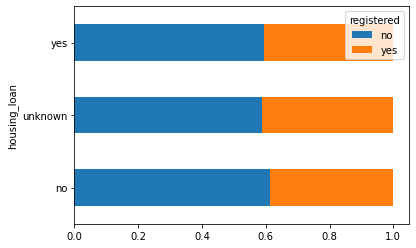

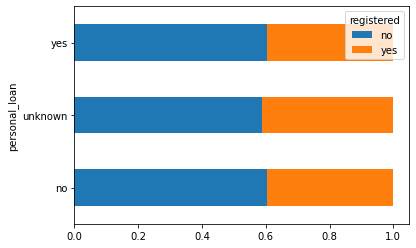

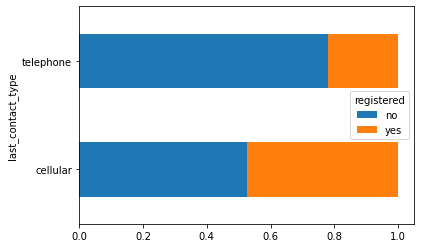

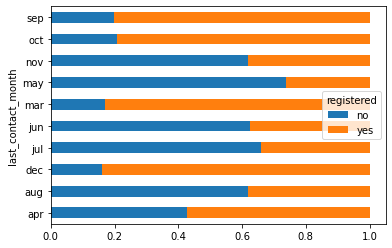

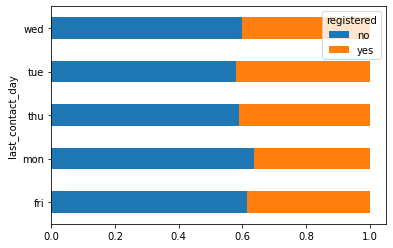

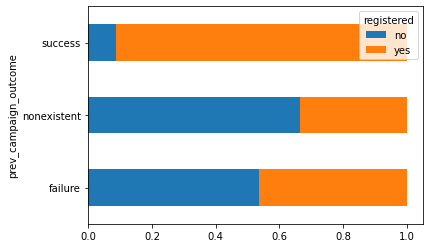

In [90]:
# Iterate over each categorical column except the last 2 (registered and location)
for column in categorical_df.columns[:-2]:

    pct_registered_df = categorical_df.groupby([column, 'registered'])[column].count()/bank_df2.groupby(column)[column].count()

    pct_registered_df.unstack().plot(kind='barh', stacked=True)
    plt.show()

- Many more students and retired registered, whereas much fewer "blue collar" and "technician" did
- It seems slightly more in the "single" status registered than those who are married or divorced
- Those in the "illiterate" category are far more likely to have registered
- Those with credit in default are 50/50 to have registered, whereas as those without credit in default none have registered
- Having a housing or personal loan does not seem to effect registering; the proportions are identical regardless of status here
- Those that were last contacted by cellular were far more likely to have registered than those contacted by "land line" (*note*: this is likely not causal, but probably has more to do with those who tend to still have land lines vs. owning a cell phone)
- The day of the week contacted does not appear to have an effect on registeration rates
- Those who were a successful conversion in a previous campaign were far more likely (~90%) to register for the term deposit product.

### Findings Summary

let's summarize what we've found from our initial analysis:

From our initial analysis let's summarize what we have found out so far about the differences between customers who register versus those who do not. 

- We have found out that younger and older people were more likely to register for the term deposit product. Perhaps these groups have less need for liquidity in the near term and can therefore sacrifice access to their funds for higher return. 

- In contrast to this, people who work in employment sectors that traditionally pay hourly, have contract based work, or where most people are self employed, were far less likely than average to sign up for this product. This is probably due to a less certain/consistent future income streams 

- People who had been contacted in previous campaigns were more likely to register for the product, however this was only a small portion of total customers.  

- People who were last contacted via cellular phone and whose last contact was of longer duration were more likely to register. Continue tracking phone type and call duration to re-target appropriately. 

- Contacts who were called during the months of September, October, December, March & April showed much higher conversion rates than those in other months. It's not entirely clear why, but it's worth noting that these months also had the lowest call volume. This merits further analysis

### Saving the data

Now that we have spent the time cleaning and exploring this dataset. We are going to save it down to file for now. In a short while, we will be using our cleaned dataset to carry out some modeling work to learn more about the customer characteristics which drive product registration! To be continued.... 

In [ ]:
bank_df2.to_csv('data/bank-marketing-data-cleaned.csv',index = False)

<div id="container" style="position:relative;">
<div style="position:relative; float:right"><img style="height:25px""width: 50px" src ="https://drive.google.com/uc?export=view&id=14VoXUJftgptWtdNhtNYVm6cjVmEWpki1" />
</div>
</div>